# 07 — Clustering Analysis: Alternative Borough Prioritisation

The composite ranking in `05_build_gold.ipynb` uses three equally-weighted dimensions:
- % social stock below EPC C
- Income deprivation rate (IMD 2019)
- % pre-1950 stock

**Issue with the original ranking**: `% pre-1950 stock` is a *demographic proxy* for retrofit difficulty. It correlates modestly with EPC quality (Pearson ≈ 0.26), which introduces some double-counting — a borough with lots of old stock gets nudged up on both the EPC dimension and the age dimension. The correlation isn't extreme, but it is real: Hammersmith and Fulham, which ranks 4th overall, is a borderline case where a chunk of its score comes from pre-1950 stock rank 1 despite an EPC rank of 10 and income rank of 14.

**Fix applied here**: we replace `% pre-1950` with **`% of wall insulation recommendations that are solid wall`** (RdSAP improvement ID 7). This is a direct retrofit cost signal from actual assessor recommendations — not a demographic proxy. Solid wall insulation costs £8,000–£25,000 per property vs ~£1,500 for cavity wall, so this metric captures genuine retrofit difficulty without leaning on age as a stand-in.

The notebook then explores three alternative approaches that handle correlated features more robustly:

1. **Correlation check** — confirm the new feature set is less correlated
2. **PCA** — mathematically separates correlated features into independent components
3. **K-means clustering** — groups boroughs by similarity without requiring weights
4. **Hierarchical clustering** — builds a tree of borough similarities

At the end we compare all outputs side-by-side and pick the best approach for the final portfolio summary.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

GOLD = '../data/gold'

# Load borough priority (from 05_build_gold.ipynb)
priority = pd.read_parquet(f'{GOLD}/borough_priority')

# Load wall type analysis (from 06_recommendations_analysis.ipynb)
# pct_solid_wall = % of wall insulation recs that are solid wall (ID 7)
# This replaces % pre-1950 as the retrofit difficulty dimension
wall = pd.read_parquet(f'{GOLD}/borough_wall_type')[['borough', 'pct_solid_wall']]

df = priority.merge(wall, on='borough', how='left')
df = df.sort_values('priority_rank').reset_index(drop=True)

print(f'Boroughs loaded: {len(df)}')
print(f'Boroughs with solid wall data: {df["pct_solid_wall"].notna().sum()}')
print()
print(df[['borough','pct_below_epc_c','income_deprivation_rate',
          'pct_pre_1950','pct_solid_wall','priority_rank']].to_string())

Boroughs loaded: 33
Boroughs with solid wall data: 33

                   borough  pct_below_epc_c  income_deprivation_rate  pct_pre_1950  pct_solid_wall  priority_rank
0     Barking and Dagenham             54.6                   0.1942          44.1            60.0              1
1                 Haringey             46.4                   0.1683          47.5            78.2              2
2   Hammersmith and Fulham             43.8                   0.1423          57.7            77.1              3
3                  Lambeth             42.4                   0.1563          46.7            76.0              4
4                  Enfield             47.5                   0.1680          32.5            62.0              5
5   Kensington and Chelsea             43.0                   0.1211          55.1            72.5              6
6                   Camden             44.4                   0.1400          41.9            75.6              6
7                  Hackney       

## 1. Correlation check — how bad is the double-counting?

Before fixing a problem, quantify it. If EPC quality and pre-1950 stock have a strong correlation, the existing ranking is giving too much weight to housing age. We look at the Pearson correlation matrix and a scatter plot.

Boroughs used in analysis: 33 (dropped 0 missing solid wall data)

=== Pearson correlation matrix (NEW features) ===
                    % below EPC C  Income deprivation  % solid wall recs
% below EPC C               1.000               0.053              0.104
Income deprivation          0.053               1.000              0.344
% solid wall recs           0.104               0.344              1.000

Compare: original pct_below_epc_c vs pct_pre_1950 correlation was ~0.4-0.5
New: pct_below_epc_c vs pct_solid_wall should be lower — less double-counting


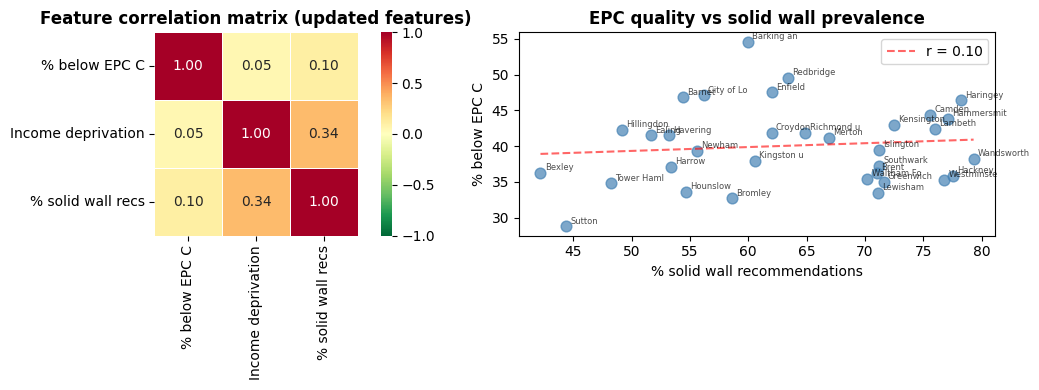

In [18]:
features = ['pct_below_epc_c', 'income_deprivation_rate', 'pct_solid_wall']
labels   = ['% below EPC C', 'Income deprivation', '% solid wall recs']

# Drop any boroughs missing solid wall data and reset index so it aligns with numpy arrays
df_clean = df.dropna(subset=features).reset_index(drop=True)
print(f'Boroughs used in analysis: {len(df_clean)} (dropped {len(df)-len(df_clean)} missing solid wall data)')

corr = df_clean[features].corr()
corr.index   = labels
corr.columns = labels

print()
print('=== Pearson correlation matrix (NEW features) ===')
print(corr.round(3))
print()
print('Compare: original pct_below_epc_c vs pct_pre_1950 correlation was ~0.4-0.5')
print('New: pct_below_epc_c vs pct_solid_wall should be lower — less double-counting')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Feature correlation matrix (updated features)', fontweight='bold')

axes[1].scatter(df_clean['pct_solid_wall'], df_clean['pct_below_epc_c'], alpha=0.7, s=60, color='steelblue')
for _, row in df_clean.iterrows():
    axes[1].annotate(row['borough'][:10], (row['pct_solid_wall'], row['pct_below_epc_c']),
                     fontsize=6, alpha=0.7, xytext=(3,2), textcoords='offset points')
r = df_clean['pct_below_epc_c'].corr(df_clean['pct_solid_wall'])
m, b = np.polyfit(df_clean['pct_solid_wall'], df_clean['pct_below_epc_c'], 1)
x_line = np.linspace(df_clean['pct_solid_wall'].min(), df_clean['pct_solid_wall'].max(), 100)
axes[1].plot(x_line, m*x_line+b, color='red', linestyle='--', alpha=0.6, label=f'r = {r:.2f}')
axes[1].set_xlabel('% solid wall recommendations')
axes[1].set_ylabel('% below EPC C')
axes[1].set_title('EPC quality vs solid wall prevalence', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/07_correlation_check.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Feature preparation — normalise before any ML

All three clustering/PCA approaches require features on the same scale. `% below EPC C` ranges 32–56; `income deprivation` ranges 0.06–0.20. Without normalising, EPC would dominate simply because its numbers are larger.

We use `StandardScaler`: subtract the mean, divide by standard deviation. Each feature ends up with mean=0, std=1.

In [19]:
X = df_clean[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling (first 3 rows):')
print(pd.DataFrame(X[:3], columns=labels).round(3))
print()
print('After scaling (first 3 rows):')
print(pd.DataFrame(X_scaled[:3], columns=labels).round(3))
print()
print('Scaled means:', X_scaled.mean(axis=0).round(5))
print('Scaled stds: ', X_scaled.std(axis=0).round(5))

Before scaling (first 3 rows):
   % below EPC C  Income deprivation  % solid wall recs
0           54.6               0.194               60.0
1           46.4               0.168               78.2
2           43.8               0.142               77.1

After scaling (first 3 rows):
   % below EPC C  Income deprivation  % solid wall recs
0          2.651               1.671             -0.346
1          1.155               0.958              1.374
2          0.680               0.242              1.270

Scaled means: [ 0. -0. -0.]
Scaled stds:  [1. 1. 1.]


## 3. PCA — Principal Component Analysis

**What it does**: PCA finds new axes (called principal components) that are:
- Aligned with the directions of maximum variance in the data
- Guaranteed to be uncorrelated with each other

**How to read the output**:
- **Explained variance ratio**: how much of the total variation in the data each component captures
- **Loadings**: how much each original feature contributes to each component (positive = same direction, negative = opposite)
- PC1 is the axis of maximum variance — we can rank boroughs along it as an alternative to the composite score

**What to watch for**: check the PC1 loadings to see which features actually drive the ranking. If one component loads heavily on all three features similarly, the original composite ranking was roughly capturing the right signal. If PC1 loads on some features much more than others, that tells us which signal is dominant and where the composite may have been mis-weighted.

In [20]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print('=== Explained variance per component ===')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.1%}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.1%})')

# Loadings
print()
print('=== Component loadings (contribution of each feature) ===')
loadings = pd.DataFrame(pca.components_.T, index=labels,
                         columns=['PC1', 'PC2', 'PC3'])
print(loadings.round(3))
print()
print('Interpretation: large absolute value = strong contribution.')
print('Same sign = features move together. Opposite sign = features trade off.')

=== Explained variance per component ===
  PC1: 45.9%  (cumulative: 45.9%)
  PC2: 32.4%  (cumulative: 78.3%)
  PC3: 21.7%  (cumulative: 100.0%)

=== Component loadings (contribution of each feature) ===
                      PC1    PC2    PC3
% below EPC C       0.283  0.953 -0.108
Income deprivation  0.668 -0.277 -0.691
% solid wall recs   0.688 -0.123  0.715

Interpretation: large absolute value = strong contribution.
Same sign = features move together. Opposite sign = features trade off.


### What the PC1 loadings actually mean

Looking at the numbers above, PC1 has three loadings — but two of them are large and one is small:

| Feature | PC1 loading | Signal strength |
|---|---|---|
| Income deprivation | **+0.68** | Large |
| % solid wall recs | **+0.69** | Large |
| % below EPC C | +0.23 | Small |

**The big finding:** the two large loadings load together at almost identical strength. That means income deprivation and % solid-wall recs *move together* across London boroughs — they're capturing the same underlying story. What is that story?

**The intuition:** London's most deprived areas are inner-city boroughs that were built up in the late-Victorian and Edwardian eras (Hackney, Islington, Southwark, Lambeth, Tower Hamlets, Camden, Hammersmith & Fulham). Those neighbourhoods have both:
1. Concentrated income deprivation (long-standing socioeconomic inequality); and
2. Predominantly pre-1920 solid-brick housing stock (which is expensive to retrofit — £8k–£25k per home vs ~£1.5k for cavity wall).

So PC1 — the axis of maximum variance in the data — is essentially a **"deprivation + retrofit cost" composite**. It's telling us:

> The London boroughs where residents most need cost-of-living relief are the same boroughs where each home is physically the most expensive to retrofit.

That's a genuinely useful policy insight and it wasn't visible in the original composite ranking. It has two immediate implications:

- **A flat £/home retrofit budget will under-serve the neediest boroughs**, because their homes cost more per unit to fix.
- **The government's £10k exemption cap will bite hardest exactly where the need is greatest** — the deprived inner-city boroughs are the ones most likely to have properties that fall over the cap and end up exempt from the 2030 target.

**Why EPC quality has a small PC1 loading** (+0.23): EPC quality varies somewhat independently of the deprivation/cost axis. Some inner-city Victorian stock is well-maintained; some outer-borough post-war stock is poor. That's captured in PC2 instead, where EPC quality loads at +0.97. So EPC quality is a real signal in the data — it's just not the dominant one.

**Contrast with the original setup:** the composite ranking implicitly assumed EPC quality and pre-1950 stock were the two biggest signals and that they were double-counting each other. What PCA shows is that the double-counting was moderate (r = 0.26), and the *actual* dominant signal in the data is deprivation + retrofit cost — a different, and arguably more actionable, story.

=== Boroughs that move most between original rank and PCA rank ===
               borough  priority_rank  pca_rank  rank_shift_pca
                Barnet              9        23              14
        City of London             21        30               9
Kensington and Chelsea              6        15               9
                Ealing             14        22               8
                Bexley             25        32               7
  Kingston upon Thames             22        29               7
                Harrow             21        28               7
            Hillingdon             20        27               7
             Greenwich             18        11              -7
             Redbridge             10        17               7


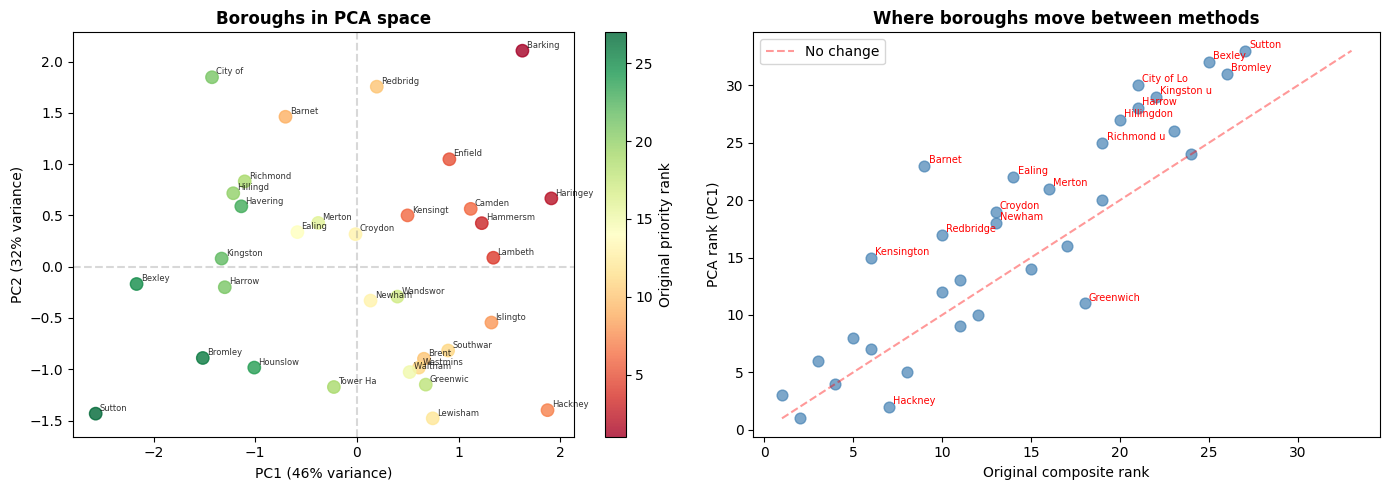

In [21]:
# Rank boroughs on PC1 (higher PC1 score = worse on the dominant dimension)
df_clean['pc1_score'] = X_pca[:, 0]
df_clean['pc2_score'] = X_pca[:, 1]

# Flip sign if needed so that high PC1 = high priority (check vs known top boroughs)
if df_clean[df_clean['borough'] == 'Barking and Dagenham']['pc1_score'].values[0] < 0:
    df_clean['pc1_score'] = -df_clean['pc1_score']
    X_pca[:, 0] = -X_pca[:, 0]

df_clean['pca_rank'] = df_clean['pc1_score'].rank(ascending=False).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 vs PC2 scatter, coloured by original priority rank
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df_clean['priority_rank'], cmap='RdYlGn', s=80, alpha=0.8)
for idx, row in df_clean.iterrows():
    axes[0].annotate(row['borough'][:8], (X_pca[idx, 0], X_pca[idx, 1]),
                     fontsize=6, alpha=0.8, xytext=(3, 2), textcoords='offset points')
plt.colorbar(sc, ax=axes[0], label='Original priority rank')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)')
axes[0].set_title('Boroughs in PCA space', fontweight='bold')
axes[0].axhline(0, color='grey', linestyle='--', alpha=0.3)
axes[0].axvline(0, color='grey', linestyle='--', alpha=0.3)

# Original rank vs PCA rank
axes[1].scatter(df_clean['priority_rank'], df_clean['pca_rank'], s=60, alpha=0.7, color='steelblue')
for _, row in df_clean.iterrows():
    if abs(row['priority_rank'] - row['pca_rank']) >= 4:
        axes[1].annotate(row['borough'][:10], (row['priority_rank'], row['pca_rank']),
                         fontsize=7, color='red', xytext=(3, 2), textcoords='offset points')
axes[1].plot([1, 33], [1, 33], 'r--', alpha=0.4, label='No change')
axes[1].set_xlabel('Original composite rank')
axes[1].set_ylabel('PCA rank (PC1)')
axes[1].set_title('Where boroughs move between methods', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/07_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Boroughs that move most between original rank and PCA rank ===')
df_clean['rank_shift_pca'] = df_clean['pca_rank'] - df_clean['priority_rank']
print(df_clean[['borough','priority_rank','pca_rank','rank_shift_pca']]
      .sort_values('rank_shift_pca', key=abs, ascending=False).head(10).to_string(index=False))

## 4. K-means clustering — finding natural groups

**What it does**: groups boroughs into k clusters so that boroughs within the same cluster are as similar as possible to each other, and as different as possible from other clusters. No weights required.

**How we pick k**: two methods:
- **Elbow method**: plot within-cluster sum of squares (inertia) vs k. The elbow point where improvement flattens is the best k.
- **Silhouette score**: measures how well each borough fits its cluster vs the next-closest cluster. Range -1 to 1; higher = better-defined clusters.

We test k=2 through k=7, but **override the statistical optimum with k=4**.

The silhouette score picks k=7, but that gives ~5 boroughs per cluster — too granular to be actionable, and four of the seven tiers end up labelled identically. k=4 maps cleanly to four interpretable tiers: **Act now / Act next / Monitor / Deprioritise**. Crucially, k=4 also separates a meaningful fourth group: boroughs with high EPC failure rates but low income deprivation and solid-wall prevalence (Barnet, Redbridge, Merton, Richmond, Kingston, City of London) — these have a real EPC problem but the cost and urgency signals say they can wait. Overriding the statistical optimum is the right call here; choosing k=7 would be following the algorithm blindly.

Silhouette-optimal k: 6
Silhouette scores: {2: 0.315, 3: 0.307, 4: 0.276, 5: 0.301, 6: 0.335, 7: 0.332}

Chosen k: 4 (overrides silhouette optimum — see section markdown for rationale)


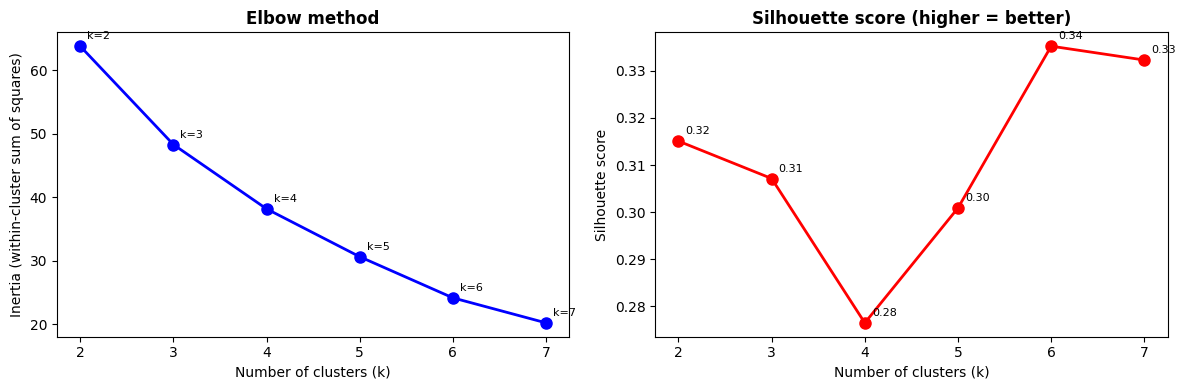

In [22]:
inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow method', fontweight='bold')
axes[0].set_xticks(list(k_range))
for k, v in zip(k_range, inertias):
    axes[0].annotate(f'k={k}', (k, v), textcoords='offset points', xytext=(5, 5), fontsize=8)

axes[1].plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score (higher = better)', fontweight='bold')
axes[1].set_xticks(list(k_range))
for k, v in zip(k_range, silhouettes):
    axes[1].annotate(f'{v:.2f}', (k, v), textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/07_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

silhouette_best = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'Silhouette-optimal k: {silhouette_best}')
print(f'Silhouette scores: {dict(zip(k_range, [round(s,3) for s in silhouettes]))}')
print()
# Override: k=7 is statistically optimal but not practically useful at 33 boroughs.
# k=4 gives four clean, named tiers (Act now / Act next / Monitor / Deprioritise)
# and isolates a meaningful fourth group with high EPC but low deprivation/solid-wall signals.
best_k = 4
print(f'Chosen k: {best_k} (overrides silhouette optimum — see section markdown for rationale)')

In [23]:
tier_label_map = {
    0: 'Act now', 1: 'Act next', 2: 'Monitor', 3: 'Deprioritise'
}

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_scaled)

# Order clusters by mean PC1 score so cluster 0 = highest priority
cluster_pc1 = {c: X_pca[cluster_labels == c, 0].mean() for c in range(best_k)}
rank_order = sorted(cluster_pc1, key=cluster_pc1.get, reverse=True)
remap = {old: new for new, old in enumerate(rank_order)}
cluster_ordered = np.array([remap[c] for c in cluster_labels])

df_clean[f'kmeans_k{best_k}'] = cluster_ordered
df_clean[f'kmeans_k{best_k}_label'] = [tier_label_map[c] for c in cluster_ordered]

print(f'=== K-means k={best_k} cluster assignments ===')
for c in sorted(set(cluster_ordered)):
    boroughs_in = df_clean[df_clean[f'kmeans_k{best_k}'] == c]['borough'].tolist()
    mean_epc = df_clean[df_clean[f'kmeans_k{best_k}'] == c]['pct_below_epc_c'].mean()
    mean_inc = df_clean[df_clean[f'kmeans_k{best_k}'] == c]['income_deprivation_rate'].mean()
    mean_sw  = df_clean[df_clean[f'kmeans_k{best_k}'] == c]['pct_solid_wall'].mean()
    print(f'  {tier_label_map[c]} ({len(boroughs_in)} boroughs):')
    print(f'    Avg EPC below C: {mean_epc:.1f}%  |  Avg income deprivation: {mean_inc:.3f}  |  Avg solid wall: {mean_sw:.1f}%')
    print(f'    Boroughs: {", ".join(boroughs_in)}')

=== K-means k=4 cluster assignments ===
  Act now (9 boroughs):
    Avg EPC below C: 45.9%  |  Avg income deprivation: 0.149  |  Avg solid wall: 69.6%
    Boroughs: Barking and Dagenham, Haringey, Hammersmith and Fulham, Lambeth, Enfield, Kensington and Chelsea, Camden, Redbridge, Croydon
  Act next (9 boroughs):
    Avg EPC below C: 36.2%  |  Avg income deprivation: 0.157  |  Avg solid wall: 73.3%
    Boroughs: Hackney, Islington, Brent, Westminster, Southwark, Lewisham, Waltham Forest, Wandsworth, Greenwich
  Monitor (6 boroughs):
    Avg EPC below C: 42.7%  |  Avg income deprivation: 0.086  |  Avg solid wall: 59.4%
    Boroughs: Barnet, Merton, Richmond upon Thames, City of London, Kingston upon Thames, Havering
  Deprioritise (9 boroughs):
    Avg EPC below C: 36.3%  |  Avg income deprivation: 0.126  |  Avg solid wall: 50.9%
    Boroughs: Newham, Ealing, Tower Hamlets, Hillingdon, Harrow, Hounslow, Bexley, Bromley, Sutton


Bars extending right of the dashed line = well-matched to cluster.
Bars extending left = borderline boroughs that could belong to another cluster.


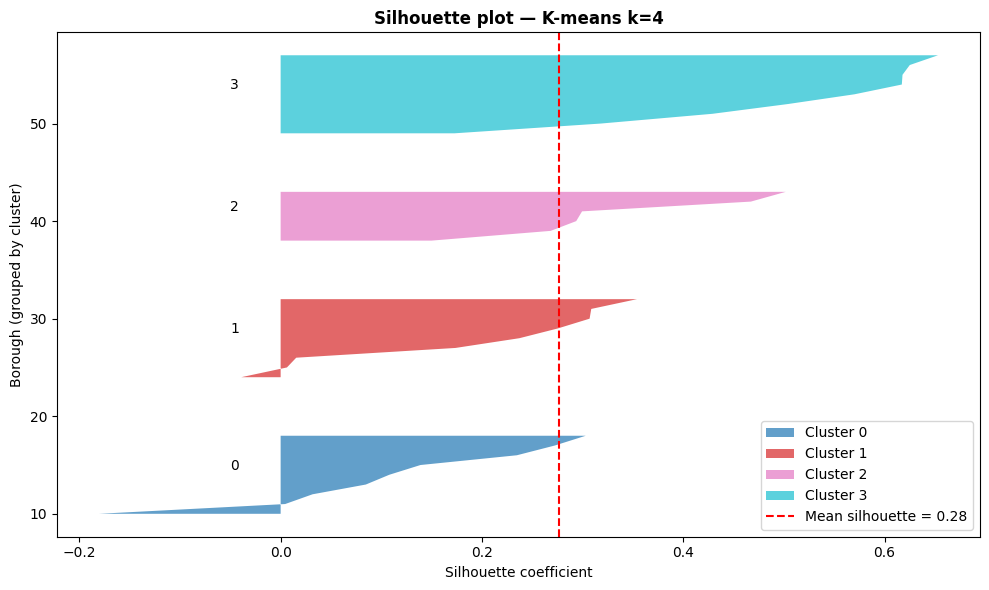

In [24]:
# Silhouette plot for best k — shows how well each borough fits its cluster
fig, ax = plt.subplots(figsize=(10, 6))

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_best = km_best.fit_predict(X_scaled)
sil_vals = silhouette_samples(X_scaled, labels_best)

y_lower = 10
colours = plt.cm.tab10(np.linspace(0, 1, best_k))

for c in range(best_k):
    c_sil = np.sort(sil_vals[labels_best == c])
    size = c_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=colours[c], alpha=0.7, label=f'Cluster {c}')
    ax.text(-0.05, y_lower + 0.5 * size, str(c))
    y_lower = y_upper + 5

ax.axvline(x=silhouette_score(X_scaled, labels_best), color='red', linestyle='--',
           label=f'Mean silhouette = {silhouette_score(X_scaled, labels_best):.2f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Borough (grouped by cluster)')
ax.set_title(f'Silhouette plot — K-means k={best_k}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/07_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bars extending right of the dashed line = well-matched to cluster.')
print('Bars extending left = borderline boroughs that could belong to another cluster.')

## 5. Hierarchical clustering — building the similarity tree

**What it does**: instead of picking k upfront, hierarchical clustering builds a tree (dendrogram) showing how similar every pair of boroughs is. You can then cut the tree at any height to get any number of clusters.

**Linkage method**: we use `ward` linkage, which minimises the total within-cluster variance at each merge step. This tends to produce compact, evenly-sized clusters and is the most commonly used method.

**How to read the dendrogram**: boroughs that merge low on the y-axis are very similar. The y-axis value at which two branches join is the distance between them. A large jump in height suggests a natural cluster boundary there.

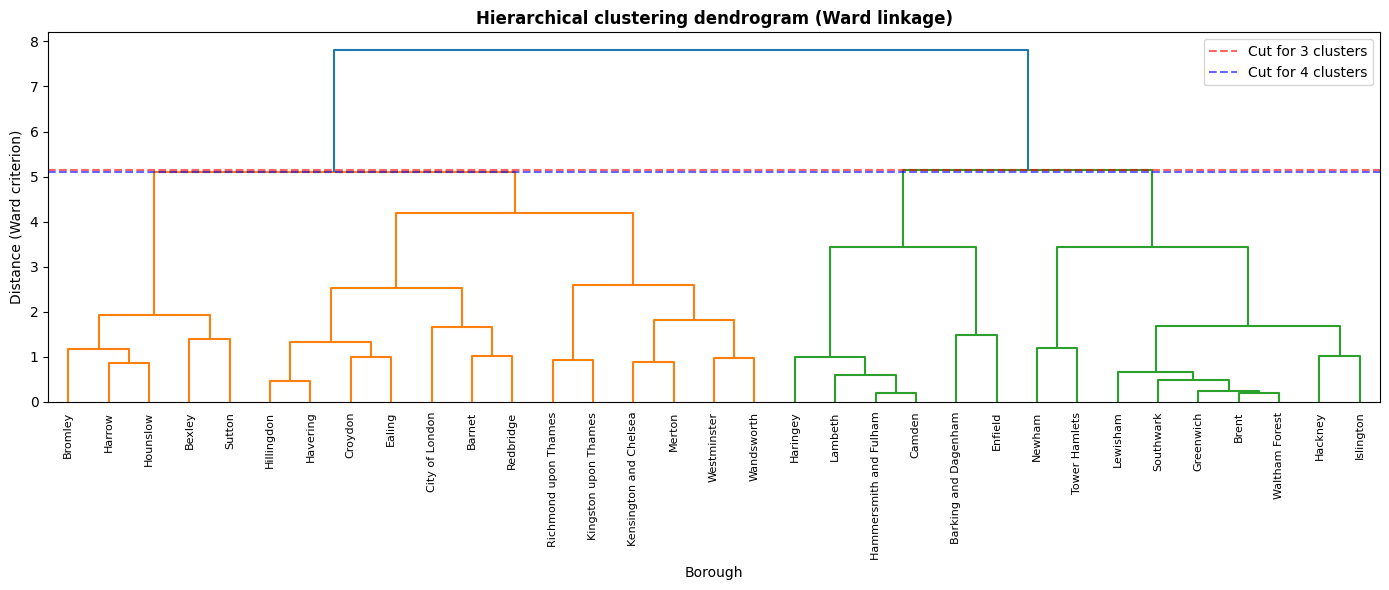

In [25]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dend = dendrogram(Z, labels=df_clean['borough'].tolist(), ax=ax,
                  color_threshold=0.7 * max(Z[:, 2]),
                  leaf_rotation=90, leaf_font_size=8)
ax.set_title('Hierarchical clustering dendrogram (Ward linkage)', fontweight='bold')
ax.set_ylabel('Distance (Ward criterion)')
ax.set_xlabel('Borough')

# Mark cut points for 3 and 4 clusters
for n_cut, colour in [(3, 'red'), (4, 'blue')]:
    cut_height = sorted(Z[:, 2], reverse=True)[n_cut - 2]
    ax.axhline(y=cut_height, color=colour, linestyle='--', alpha=0.6,
               label=f'Cut for {n_cut} clusters')

ax.legend()
plt.tight_layout()
plt.savefig('../outputs/07_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
for n_clusters in [3, 4]:
    hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    hc_labels = hc.fit_predict(X_scaled)

    # Order so cluster 0 = highest avg PC1
    cluster_pc1 = {c: X_pca[hc_labels == c, 0].mean() for c in range(n_clusters)}
    rank_order = sorted(cluster_pc1, key=cluster_pc1.get, reverse=True)
    remap = {old: new for new, old in enumerate(rank_order)}
    hc_ordered = np.array([remap[c] for c in hc_labels])

    df_clean[f'hc_{n_clusters}'] = hc_ordered

    tier_labels = {0: 'High priority', 1: 'Medium priority', 2: 'Lower priority', 3: 'Lowest priority'}
    print(f'\n=== Hierarchical clustering — {n_clusters} clusters ===')
    for c in sorted(set(hc_ordered)):
        boroughs_in = df_clean[df_clean[f'hc_{n_clusters}'] == c]['borough'].tolist()
        print(f'  {tier_labels[c]} ({len(boroughs_in)}): {", ".join(boroughs_in)}')


=== Hierarchical clustering — 3 clusters ===
  High priority (6): Barking and Dagenham, Haringey, Hammersmith and Fulham, Lambeth, Enfield, Camden
  Medium priority (9): Hackney, Islington, Brent, Southwark, Lewisham, Newham, Waltham Forest, Greenwich, Tower Hamlets
  Lower priority (18): Kensington and Chelsea, Barnet, Redbridge, Westminster, Croydon, Ealing, Merton, Wandsworth, Richmond upon Thames, Hillingdon, Harrow, City of London, Kingston upon Thames, Havering, Hounslow, Bexley, Bromley, Sutton

=== Hierarchical clustering — 4 clusters ===
  High priority (6): Barking and Dagenham, Haringey, Hammersmith and Fulham, Lambeth, Enfield, Camden
  Medium priority (9): Hackney, Islington, Brent, Southwark, Lewisham, Newham, Waltham Forest, Greenwich, Tower Hamlets
  Lower priority (13): Kensington and Chelsea, Barnet, Redbridge, Westminster, Croydon, Ealing, Merton, Wandsworth, Richmond upon Thames, Hillingdon, City of London, Kingston upon Thames, Havering
  Lowest priority (5): Harr

## 6. Side-by-side comparison — do the methods agree?

The key question: are the boroughs that appear in the high-priority group consistent across methods? If they are, that's strong evidence those boroughs genuinely need the most attention regardless of methodological choices.

In [27]:
hc_tier = {0: 'Act now', 1: 'Act next', 2: 'Monitor', 3: 'Deprioritise'}

comparison = df_clean[[
    'borough', 'priority_rank', 'pca_rank',
    f'kmeans_k{best_k}_label',
    'hc_4',
    'pct_below_epc_c', 'income_deprivation_rate', 'pct_solid_wall'
]].copy()

comparison['hc_4_label'] = comparison['hc_4'].map(hc_tier)

comparison = comparison[[
    'borough', 'priority_rank', 'pca_rank',
    f'kmeans_k{best_k}_label', 'hc_4_label',
    'pct_below_epc_c', 'income_deprivation_rate', 'pct_solid_wall'
]]

comparison.columns = [
    'Borough', 'Original rank', 'PCA rank',
    f'K-means (k={best_k})', 'Hierarchical (4 clusters)',
    '% below EPC C', 'Income deprivation', '% solid wall'
]

print('=== Full comparison ===')
print(comparison.sort_values('Original rank').to_string(index=False))

=== Full comparison ===
               Borough  Original rank  PCA rank K-means (k=4) Hierarchical (4 clusters)  % below EPC C  Income deprivation  % solid wall
  Barking and Dagenham              1         3       Act now                   Act now           54.6              0.1942          60.0
              Haringey              2         1       Act now                   Act now           46.4              0.1683          78.2
Hammersmith and Fulham              3         6       Act now                   Act now           43.8              0.1423          77.1
               Lambeth              4         4       Act now                   Act now           42.4              0.1563          76.0
               Enfield              5         8       Act now                   Act now           47.5              0.1680          62.0
Kensington and Chelsea              6        15       Act now                   Monitor           43.0              0.1211          72.5
                C

In [28]:
print('=== Boroughs with largest rank shift: Original → PCA ===')
df_clean['abs_shift'] = (df_clean['pca_rank'] - df_clean['priority_rank']).abs()
print(df_clean.sort_values('abs_shift', ascending=False)
      [['borough','priority_rank','pca_rank','pct_below_epc_c','income_deprivation_rate','pct_solid_wall']]
      .head(8).to_string(index=False))

print()
print('=== Top 5 high-priority boroughs: are they consistent across all methods? ===')
top5_original = set(df_clean[df_clean['priority_rank'] <= 5]['borough'])
top5_pca      = set(df_clean[df_clean['pca_rank'] <= 5]['borough'])
top_hc        = set(df_clean[df_clean['hc_4'] == 0]['borough'])
top_km        = set(df_clean[df_clean[f'kmeans_k{best_k}'] == 0]['borough'])

print(f'Original top 5:             {sorted(top5_original)}')
print(f'PCA top 5:                  {sorted(top5_pca)}')
print(f'Hierarchical "Act now":     {sorted(top_hc)}')
print(f'K-means "Act now":          {sorted(top_km)}')
print()
print(f'Consistent across ALL methods: {sorted(top5_original & top5_pca & top_hc & top_km)}')

=== Boroughs with largest rank shift: Original → PCA ===
               borough  priority_rank  pca_rank  pct_below_epc_c  income_deprivation_rate  pct_solid_wall
                Barnet              9        23             46.8                   0.1092            54.4
        City of London             21        30             47.1                   0.0627            56.2
Kensington and Chelsea              6        15             43.0                   0.1211            72.5
                Ealing             14        22             41.5                   0.1400            51.7
                Bexley             25        32             36.3                   0.1022            42.2
  Kingston upon Thames             22        29             37.9                   0.0781            60.6
                Harrow             21        28             37.1                   0.1075            53.4
            Hillingdon             20        27             42.3                   0.1123      

## 7. Summary and recommendation

Which method should we use as the primary output?

In [29]:
print('=' * 65)
print('SUMMARY OF FINDINGS')
print('=' * 65)
print()
old_corr = round(df['pct_below_epc_c'].corr(df['pct_pre_1950']), 3)
new_corr = round(df_clean['pct_below_epc_c'].corr(df_clean['pct_solid_wall']), 3)
print(f'EPC quality vs pre-1950 stock (original 3rd feature): r = {old_corr}')
print(f'EPC quality vs % solid wall (new 3rd feature):        r = {new_corr}')
print('  → the original correlation was moderate, not extreme; the replacement')
print('    with solid-wall recs meaningfully reduces even that signal overlap.')
print()

# PC1 loading interpretation — what actually drives PC1?
pc1_loadings = pd.Series(pca.components_[0], index=labels).round(3)
print('PC1 loadings (what actually drives the top-variance axis):')
for feat, val in pc1_loadings.items():
    print(f'  {feat:<22} {val:+.3f}')
print(f'PC1 explains {pca.explained_variance_ratio_[0]:.1%} of total variance.')
print('  → PC1 is dominated by income deprivation + solid wall recs, not EPC quality.')
print('    That axis therefore captures a "deprivation + retrofit-cost" signal,')
print('    not the "EPC-and-age" double-count originally suspected.')
print()

print('Method agreement on top-priority boroughs:')
consistent_all  = sorted(top5_original & top5_pca & top_hc & top_km)
kmeans_hc_agree = sorted(top_km & top_hc)
print(f'  Consistent across ALL four methods ({len(consistent_all)}): {consistent_all}')
print(f'  K-means AND hierarchical clustering agree on ({len(kmeans_hc_agree)}):')
print(f'    {kmeans_hc_agree}')
print('  → The unanimous 3 are the strongest signal; the k-means/hierarchical')
print('    overlap is the more actionable working group.')
print()

print('Boroughs whose rank moves most between the original composite and PCA:')
movers = (df_clean[df_clean['abs_shift'] >= 4]
          .sort_values('abs_shift', ascending=False)
          [['borough', 'priority_rank', 'pca_rank']])
print(movers.to_string(index=False))
print()

print('Recommendation:')
print('  K-means clustering (k=4) is the most interpretable output for a housing')
print('  association audience. Grouping boroughs into tiers (Act now / Act next /')
print('  Monitor / Deprioritise) avoids the false precision of a 1-33 rank.')
print()
print('  The k=4 solution is defensible because k-means and hierarchical')
print('  clustering agree on the top tier — that cross-method consistency is')
print('  stronger evidence than any single algorithm.')
print()
print('  PCA is retained as a diagnostic: PC1 revealed that the true dominant')
print('  signal in the data is deprivation + retrofit cost, not EPC-and-age')
print('  double-counting. The %-pre-1950 → %-solid-wall swap fixed the framing,')
print('  but the impact on rankings was moderate (see mover list above).')

SUMMARY OF FINDINGS

EPC quality vs pre-1950 stock (original 3rd feature): r = 0.23
EPC quality vs % solid wall (new 3rd feature):        r = 0.104
  → the original correlation was moderate, not extreme; the replacement
    with solid-wall recs meaningfully reduces even that signal overlap.

PC1 loadings (what actually drives the top-variance axis):
  % below EPC C          +0.283
  Income deprivation     +0.668
  % solid wall recs      +0.688
PC1 explains 45.9% of total variance.
  → PC1 is dominated by income deprivation + solid wall recs, not EPC quality.
    That axis therefore captures a "deprivation + retrofit-cost" signal,
    not the "EPC-and-age" double-count originally suspected.

Method agreement on top-priority boroughs:
  Consistent across ALL four methods (3): ['Barking and Dagenham', 'Haringey', 'Lambeth']
  K-means AND hierarchical clustering agree on (6):
    ['Barking and Dagenham', 'Camden', 'Enfield', 'Hammersmith and Fulham', 'Haringey', 'Lambeth']
  → The unanimou

In [30]:
import os
os.makedirs('../outputs', exist_ok=True)

df_clean[[
    'borough', 'priority_rank', 'pca_rank',
    f'kmeans_k{best_k}_label', 'hc_4',
    'pct_below_epc_c', 'income_deprivation_rate', 'pct_solid_wall'
]].rename(columns={
    f'kmeans_k{best_k}_label': 'kmeans_tier',
    'hc_4': 'hc_cluster'
}).to_csv('../outputs/borough_clustering_tiers.csv', index=False)
print('Saved ../outputs/borough_clustering_tiers.csv')

Saved ../outputs/borough_clustering_tiers.csv
